<a href="https://colab.research.google.com/github/htenaj8864-cmyk/analisis-everpeak/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna() .sum())# Cantidad de valores nulos)
print(users.isna() .mean()) # Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna() .sum())# Cantidad de valores nulos)
print(usage.isna() .mean()) # Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Las columnas que tienen valores faltantes para **users** son: city (12%) y churn_date (88%); mientras que para **usage** las columnas con valores faltantes son:date (menor al 1%), duration(55%) y length (45%).

- Indica qué harías: ¿imputar, eliminar, ignorar?
- En las columnas que presentan un porcentaje del menor del 5% como lo es date en usage, validaría si se puede recuperar la información con el equipo y en caso de no ser así, los dejaría como nulos.
- Para las columnas del 5% al 30% como lo son city para users, validaría si se puede recuperar la información con el equipo y en caso de no ser así, los dejaría como nulos.
- Por último las columnas mayores al 40% no serían confiables, sin embargo en este caso particular las columnas que tienen este porcentaje como lo son churn_date para **users** y duration y length para **usage** nos estan diciendo que es una categoría por lo tanto realizaría una imputación.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users["user_id"].value_counts()

10241    1
11583    1
13604    1
11559    1
13608    1
        ..
10916    1
12967    1
10920    1
12971    1
10239    1
Name: user_id, Length: 4000, dtype: int64

In [ ]:
users["user_id"].describe()

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

In [ ]:
users["age"].value_counts()

50    86
30    81
78    79
33    74
36    74
      ..
57    54
51    54
62    51
68    51
70    45
Name: age, Length: 63, dtype: int64

In [ ]:
users["age"].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

Haz doble clic en este bloque y escribe qué ves.
- La columna `user_id` con .value_counts() nos muestra que contiene 4000 datos, también nos confirma que no hay duplicaciones o faltantes de datos y todo esta en números enteros, mientras que con .describe() al observar que la media y la mediana son exactamente iguales nos dice que tenemos una distribución de datos simétrica lo que significa que no tenemos valores atípicos.
- La columna `age` con .value_counts() encontramos que el total de edades diferentes es de 63 y que la edad de 50 años es la más frecuente y que la de menor frecuencia es de 45 años. Al revisar con .describe() se observa que la edad minima es -999 lo cual nos dice que la columna tiene información incorrecta.

In [ ]:
# explorar columnas numéricas de usage
usage["id"].value_counts()

2049     1
35492    1
25241    1
31386    1
29339    1
        ..
17730    1
19779    1
30020    1
32069    1
2047     1
Name: id, Length: 40000, dtype: int64

In [ ]:
usage["id"].describe()

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

In [ ]:
usage["user_id"].value_counts()

13819    27
13100    22
13772    22
13255    22
13475    21
         ..
12448     2
11891     2
10226     2
13923     2
12058     1
Name: user_id, Length: 3999, dtype: int64

In [ ]:
usage["user_id"].describe()

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

Haz doble clic en este bloque y escribe qué ves.
- Las columnas `id` .value_counts() y .describe() nos muestra que no hay huecos ni faltantes en los datos para esta columna.
- Las columnas  `user_id`en .value_counts() para esta columna nos dice que usuario 13819 es el que presenta mayor frecuencia de registros, mientras que el usuario 12058 solo un registro, también nos dice que el total de usuarios unicos es de 3999, mientras que .describe() nos muestra que tenemos 40000 filas.

In [ ]:
# explorar columna categórica de users
users['city'] # completa el código

0       Medellín
1              ?
2           CDMX
3         Bogotá
4            GDL
          ...   
3995    Medellín
3996    Medellín
3997      Bogotá
3998      Bogotá
3999      Bogotá
Name: city, Length: 4000, dtype: object

In [ ]:
users["city"].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
users["plan"].describe()

count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object

In [ ]:
users["plan"].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` con .describe() se observa que la columna presenta 3531 datos en total de los cuales 7 son unicos y la ciudad que más frecuencia tiene es Bogotá, mientras que con .value_counts() nos muestra que de las 7 categorías unicas que presenta tenemos un valor ? el cual tenemos que identificar como sentinel.
- La columna `plan` presenta 4000 datos en total de los cuales 2 son unicos y el plan que más frecuencia tiene es el Basico.

In [ ]:

# explorar columna categórica de usage
usage['type'].describe() # completa el código


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` presenta un total de 40000 datos de los cuales hay dos categorias,la que tiene mas frecuencia es text.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Las columnas que presentan valores inválidos son: city y age.
- ¿Qué acción tomarías?
- El primer paso sería revisar con el equipo si se puede rescatar esta información y por otro lado realizaría para city un filtro con .isin para ver cuantos datos tiene este valor y así tomar la desición si se imputan como NAN o se descartan las filas y para age aplicaría un filtro .isin con .sum para revisar el número de casos que tienen mal el valor y así mismo tomar la desición de imputar con la mediana o descartarlas.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")  # completa el código

In [ ]:
users['año'] = users["reg_date"].dt.year

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")# completa el código

In [ ]:
usage['año'] = usage["date"].dt.year

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['año'].unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, se observa que en la columna de año tenemos 2022, 2026, 2023 y 2024 ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['año'].unique()

array([2024.,   nan])

En `date`, se observa el año 2024 sin embargo también tenemos datos nulos... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? para la columna reg_date revisaría más a fondo el año 2026 ya que la información es hasta el 2024 y para la columna date nos aparecen datos nulos(años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas? para el caso de reg_date revisaría las filas que tienen el año 2026 usando un filtro .copy() para visualizar la información y saber si son errores faciles de corregir para imputar o eliminar dependiento del número de datos y para date, revisar cuantos datos tenemos nulos convertir a NAN y después imputar o eliminar según la cantidad de datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = np.where(users['reg_date'] > '2026-12-31', pd.NA, users['reg_date'])

# Verificar cambios
users['reg_date'].isna().sum()

0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`
- Esta exploración confirma que los valores faltantes en duration y length son MAR (Missing At Random), ya que dependen directamente del tipo de evento (type). LA lógica del dominio es un comportamiento esperado del sistema. Una llamada (call) tiene duración pero no longitud de texto. Un mensaje de texto (text) tiene longitud pero no duración de tiempo. Con todo, se dejan los valores como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
users.describe()

,user_id,age,año
count,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.136000,2023.034000
std,1154.844867,17.689919,0.866044
min,10000.000000,18.000000,2022.000000
25%,10999.750000,33.000000,2022.000000
50%,11999.500000,48.000000,2023.000000
75%,12999.250000,63.000000,2024.000000
max,13999.000000,79.000000,2026.000000


In [ ]:
usage.describe()

,id,user_id,duration,length,año,is_text,is_call
count,40000.00000,40000.000000,17924.000000,22104.000000,39950.0,40000.000000,40000.000000
mean,20000.50000,12002.405975,5.202237,52.127398,2024.0,0.552300,0.447700
std,11547.14972,1157.279564,6.842701,56.611183,0.0,0.497263,0.497263
min,1.00000,10000.000000,0.000000,0.000000,2024.0,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000,2024.0,0.000000,0.000000
50%,20000.50000,12013.000000,3.500000,50.000000,2024.0,1.000000,0.000000
75%,30000.25000,13005.000000,6.990000,64.000000,2024.0,1.000000,1.000000
max,40000.00000,13999.000000,120.000000,1490.000000,2024.0,1.000000,1.000000


In [ ]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

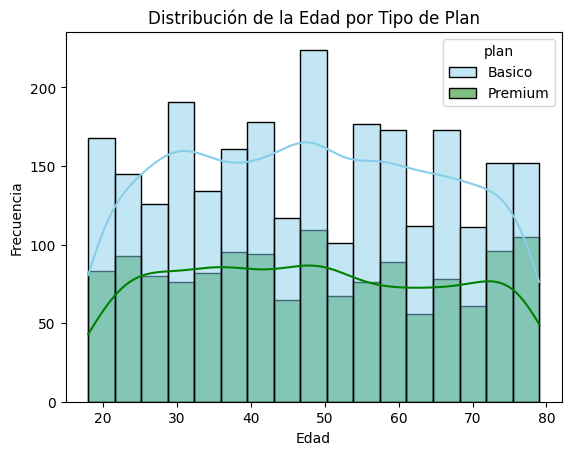

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", palette=['skyblue', 'green'], kde=True)

plt.title("Distribución de la Edad por Tipo de Plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

💡Insights:
- La edad no parece ser un factor determinante para la elección del tipo de plan, ya que la distribución es simetrica entre los 18 y 80 años para ambos grupos. Sin embargo, el plan Básico domina la preferencia en todos los rangos de edad.

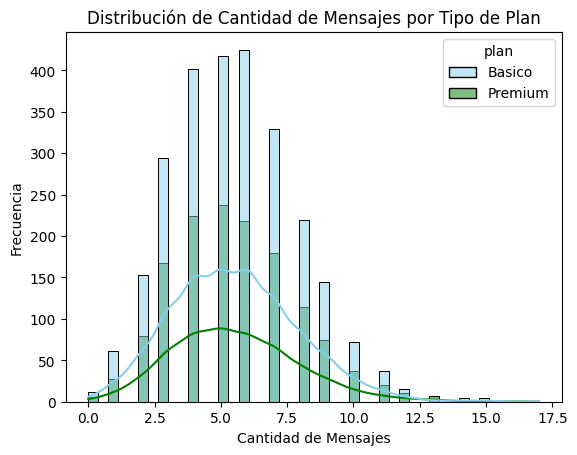

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=['skyblue', 'green'], kde=True)
plt.title("Distribución de Cantidad de Mensajes por Tipo de Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- La distribución de la cantidad de mensajes está sesgada a la derecha en ambos planes, con la mayor concentración de usuarios enviando entre 3 y 7 mensajes. El comportamiento de consumo es bastante similar entre los usuarios de los planes Básico y Premium, aunque el plan Básico abarca la mayor proporción de volumen.

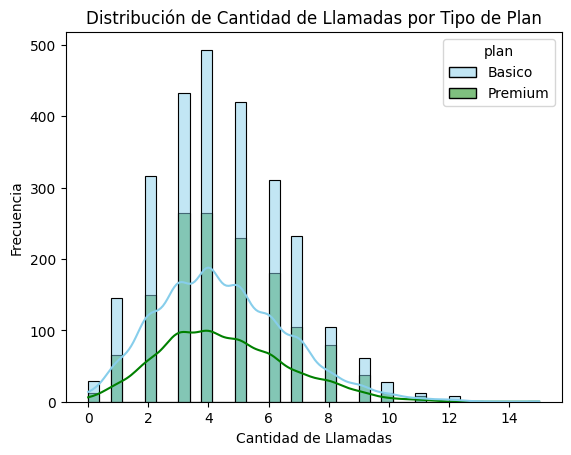

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=['skyblue', 'green'], kde=True)
plt.title("Distribución de Cantidad de Llamadas por Tipo de Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- La cantidad de llamadas presenta una distribución sesgada a la derecha, donde la mayoría de los usuarios en ambos planes realiza entre 2 y 6 llamadas (con un pico en 4). El patrón de consumo es prácticamente idéntico entre los usuarios Básico y Premium, concentrándose el mayor volumen en el plan Básico.

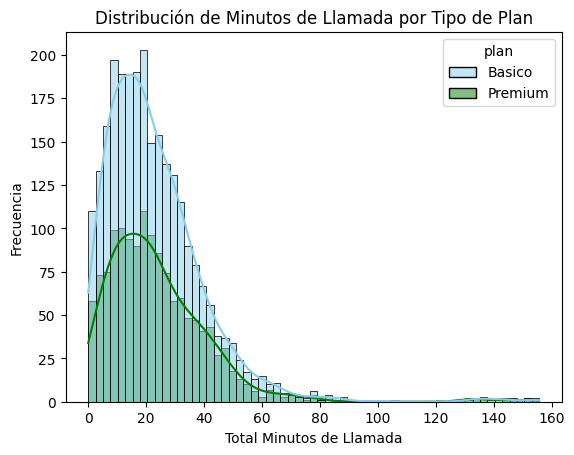

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=['skyblue', 'green'], kde=True)
plt.title("Distribución de Minutos de Llamada por Tipo de Plan")
plt.xlabel("Total Minutos de Llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- La duración total de llamadas presenta una distribución altamente sesgada a la derecha, concentrándose la mayoría de los usuarios entre los 5 y 35 minutos (con un pico en ~18 minutos). Los usuarios del plan Premium presentan un patrón de consumo de minutos casi idéntico al de los usuarios del plan Básico, registrándose además valores atípicos aislados superando los 130 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

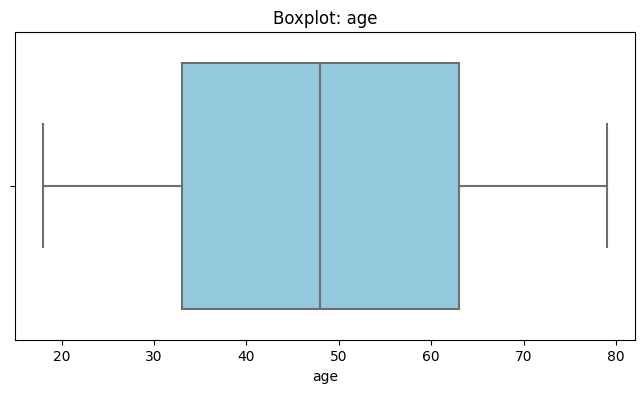

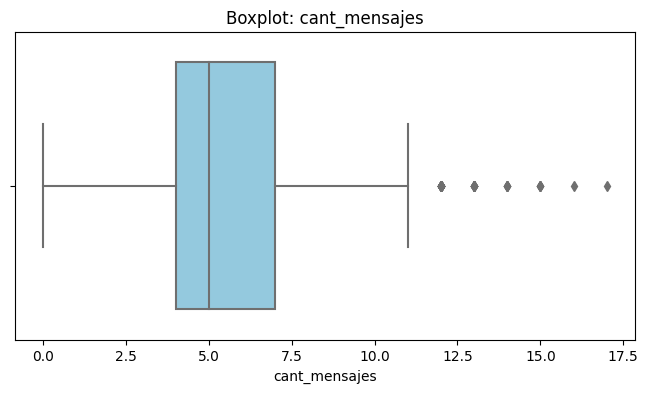

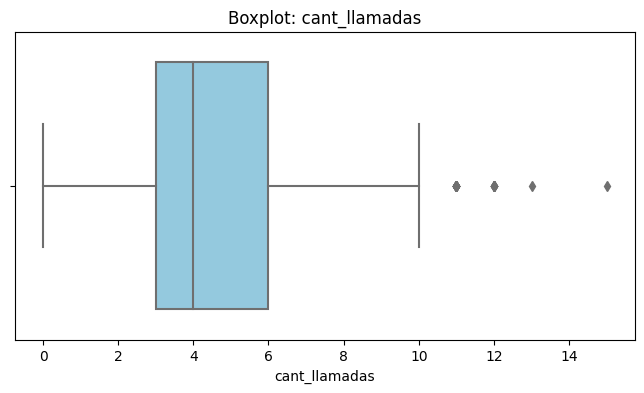

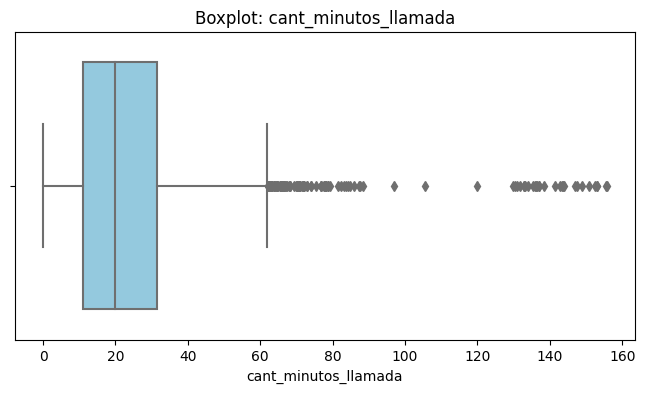

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}') # Aplicando el formato solicitado en el Hint
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: no outliers
- cant_mensajes: si presenta outliers
- cant_llamadas: si presenta outliers
- cant_minutos_llamada: si presenta outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"=== Variable: {col} ===")
    print('primer cuartil:', Q1)
    print('tercer cuartil:', Q3)
    print('IQR:', IQR)
    print('límite superior:', limite_superior)
    print("-" * 30)


=== Variable: cant_mensajes ===
primer cuartil: 4.0
tercer cuartil: 7.0
IQR: 3.0
límite superior: 11.5
------------------------------
=== Variable: cant_llamadas ===
primer cuartil: 3.0
tercer cuartil: 6.0
IQR: 3.0
límite superior: 10.5
------------------------------
=== Variable: cant_minutos_llamada ===
primer cuartil: 11.12
tercer cuartil: 31.415
IQR: 20.295
límite superior: 61.8575
------------------------------


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: **mantener outliers**, porqué? Porque el límite superior teórico es **11.5** mensajes y el valor máximo real es **17**. Un máximo de 17 mensajes no es un error de medición ni un valor imposible de registrar en la realidad; refleja simplemente a un grupo de usuarios de alto consumo.
- cant_llamadas: **mantener outliers**, porqué? Porque el límite superior es **10.5** llamadas y el valor máximo registrado es **15**. Realizar hasta 15 llamadas dentro de un periodo representa un patrón de uso legítimo y plausible dentro de los hábitos normales de los clientes.
- cant_minutos_llamada: **mantener outliers**, porqué? Porque el límite superior es de **61.86** minutos y el máximo llega a **155.69** minutos (un usuario con poco más de 2.5 horas acumuladas). Este consumo es completamente viable en el servicio y aporta información valiosa sobre los clientes de alto uso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

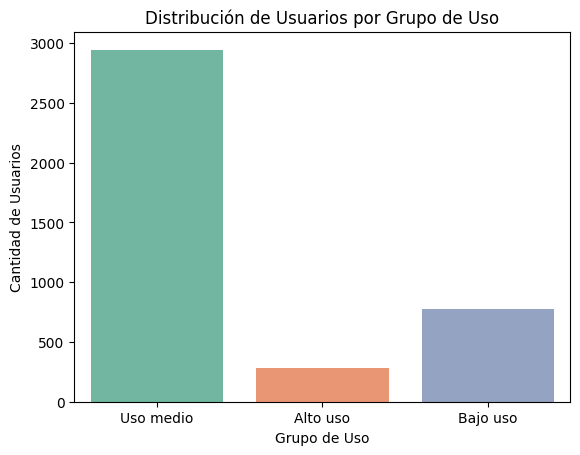

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='Set2')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')


plt.show()

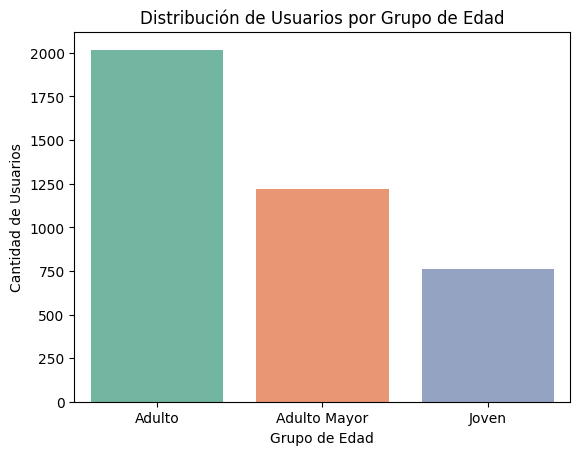

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Set2')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

- Problemas detectados con los datos:
- En el Dataset: **users-->** las siguientes variables fueron detectadas con problemas: **churn_date:* presentaba valores nulos por clientes activos (Missing) 3,534 filas (88.35%), **city:* presentaba valores faltantes (NaN) y código sentinel (?) 469 nulos (11.73%) + 96 "?" (2.40%) --> 565 filas incompletas (14.13%), **age:* presento código sentinel de edad inválida (-999) 305 filas (7.63%) y **reg_date:* fechas fuera de rango/imposibles (año 2026 en datos a 2024) Registros con año 2026 (inconsistencia de captura).
- En el Dataset: **usage-->** las variables detectadas con errores fueron las siguientes: **duration:* presento ausencias por tipo de registro (Missing At Random) 22,076 nulos (55.19%) (corresponden a mensajes de texto), **length:* presento ausencias por tipo de registro (Missing At Random) 17,896 nulos (44.74%) (corresponden a llamadas de voz y por último **date:* fechas faltantes 50 filas (0.13%).
-
- Segmentos por edad:
-  Se divide en 3 grupos **Joven** (<30 años), **Adulto** (30-59 años) y **Adulto mayor** (mayores de 60 años). La edad presenta una distribución simétrica (de 18 a 80 años) en ambos tipos de planes. Los jóvenes, adultos y adultos mayores consumen minutos y mensajes de forma prácticamente homogénea, por lo que la edad no condiciona la contratación del plan Premium.
-
- Segmentos por nivel de uso:
- Se dive en 3 grupos **Uso bajo:** (<5 llamadas y <5 mensajes), **Uso Medio:** (<10 llamadas y <10 mensajes) y **Uso Alto:** (mayores a 10 llamadas o mayores a 10 mensajes). En la segmentación de **Uso bajo** se concentra a los usuarios con consumo ocasional, con promedio de consumo muy por debajo de los límites incluidos en ambos planes. Para los usuarios de **Uso Medio:** son el núcleo operativo de la base de clientes, presenta picos de volumen regular alrededor de 4 llamadas y entre 3 y 7 mensajes, mientras que para los usuarios **Uso Alto: (Power users)** son de consumo intensivo. Registran tráfico recurrente en minutos y SMS, acercándose o superando los promedios del mercado.
-
- El segmento más valioso: es el segmento de alto Uso **Power Users** porque tienen la mayor tasa de utilización de la red y generan mayor oportunidad de ingreso recurrente. Al ser usuarios activos, dependen fuertemente del servicio y presentan menor sensibilidad al precio si la calidad de la red es alta. **Usuarios en Plan Básico** con consumo medio-alto: porque representan el 64.88% de la base de clientes. Aquellos que bordean los límites de su tarifa plana son altamente rentables por los cobros de excedentes, y constituyen el target primario para estrategias de upselling (migración a Premium).
-
- Los patrones detectados (límites leóricos IQR vs. máximos reales):para mensajes el límite superior teóricamente de **11.5** SMS --> máximo real: 17 mensajes. Para las llamadas el límite superior teóricamente de **10.5** llamadas --> Máximo real: 15 llamadas. Para los minutos de llamada el límite superior teóricamente de **61.86** minutos --> Máximo real: 155.69 minutos (~2.5 horas acumuladas).
- Las implicaciones para el negocio: **legitimidad:** no corresponden a errores de medición ni a fraude; reflejan uso real legítimo de clientes intensivos. **Margen por Excedentes:** En el plan Básico, los usuarios con consumo extremo de minutos generan altos ingresos adicionales por tarifa excedente . **Riesgo de Churn:** Si la penalización por excedentes en el plan Básico resulta desproporcionada, estos usuarios intensivos podrían migrar hacia competidores con planes ilimitados o paquetes más competitivos.
-
- Recomedaciones:
-  Rediseño del Plan Premium:
  **Problema:** Los usuarios del plan Premium muestran patrones de consumo de voz y SMS idénticos a los del plan Básico.
  **Propuesta:** Incluir diferenciadores de valor agregado en el plan Premium que no dependen exclusivamente de minutos o mensajes (ej. mayor bolsa de GB para navegación, acceso a plataformas de streaming o roaming internacional).
- Creación de un Plan Intermedio :Dirigido al segmento de Uso Medio y Alto en Plan Básico que suele pagar excedentes pero duda en duplicar su tarifa . Podría ofrecer mas minutos y mas mensajes que el plan básico.
- Estrategia de Fidelización para el Segmento de Alto Uso: Empaquetar ofertas personalizadas de retención para evitar que los power users que generan excedentes recurrentes abandonen la compañía.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`